<p style="text-align:center;text-justify:inter-word;"><img src="../LabDataScience.png" alt="Seja bem vindo ao meu laboratório de ciência de dados!" width="800" height="600"></p>

# Redução de Churn de Companhia Telefônica #

## 📓 Fase 03 — Data Preparation ##

### Objetivo: ###

- **Tratar missing**  
- **Encoding correto**  
- **Split estratificado**
- **Pipeline reutilizável**
- **Sem data leakage**

## Carregando Bibliotecas ##

In [1]:
#carregando as bibliotecas


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## importando bibliotecas scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score

## Funções ##


In [2]:
def CriarConfusao (y_t, y_p):
    # =========================================
    # Matriz de Confusão — leitura visual
    # =========================================
    # A matriz de confusão mostra os acertos/erros em termos absolutos:
    #
    #                Predito 0     Predito 1
    # Real 0 (não churn)      TN          FP
    # Real 1 (churn)          FN          TP
    #
    # Para churn, o mais perigoso é FN:
    # - FN = churn real que o modelo deixou escapar
    # Isso significa perder cliente sem agir.
    cm = confusion_matrix(y_t, y_p)
    plt.figure(figsize=(5,4))
    plt.imshow(cm)  # não definimos cores manualmente (fica no padrão do matplotlib)
    plt.title("Matriz de Confusão (Logistic Regression)")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.xticks([0, 1], ["Não churn (0)", "Churn (1)"])
    plt.yticks([0, 1], ["Não churn (0)", "Churn (1)"])
        # Anotar os valores dentro da matriz
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    
    plt.tight_layout()
    plt.show()

## Carregando o Dataset

In [3]:

# importando dados do dataset para um dataframe 
df = pd.read_csv("telecom_churn_synthetic.csv")


## 1. Separar Target e Features ##

In [4]:
# retirando as colunas customer_id e churn e atribuindo novo dataset à variável X
X = df.drop(columns=["customer_id", "churn"])

# separando a coluna target "churn" e atribuindo à variável y
y = df["churn"]

## 2. Identificar tipos de variáveis ##

In [5]:
# explicando os comandos:

# # X.select_dtypes vai selecionar  do data frame X seguindo os critérios definidos
# # No nosso caso: 
# # # include=["object", "category", "string"] e 
# # # exclude=["object", "category", "string"]


# include=["object"] - Seleciona apenas dados cujo tipo é object
# No pandas, object normalmente significa:
# # texto (string)
# # categorias armazenadas como texto

cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()


# exclude="object" Seleciona dados que não é do tipo object (texto).
# Ou seja:
# #inteiros (int)
# #floats (float)
# # booleanos (bool)

num_cols = X.select_dtypes(exclude=["object", "category", "string"]).columns.tolist()


## .columns: Pega apenas os nomes das colunas selecionadas.

## .tolist(): Converte os nomes das colunas para uma lista Python.


#mostrando o conteúdo das novas variáveis cat_cols e num_cols
# cat_cols, num_cols

## 3. Split Estratificado (ANTES de qualquer transformação!) ##

📌 Isso mantém os ~14% de churn nas duas bases.

Se não fizer isso → modelo enviesado.


In [6]:
# usando comando da biblioteca sklearn importado anteriormente

#separando conjuntos de treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

## 4. Construindo o Pipeline Correto ##

Um pipeline é uma sequência organizada de etapas de processamento aplicadas automaticamente aos dados. É a forma estruturada de garantir que o mesmo pré-processamento seja aplicado antes do modelo, sempre na mesma ordem.

⚠️**Agora vem o ponto crítico:**

    👉 Transformações devem aprender só com treino.

**📌 Diferença Entre Pipeline e ColumnTransformer**

#### 1️⃣ Pipeline ####

🔹🔹Aplica etapas sequenciais no dataset inteiro.

🔹🔹Uma coisa depois da outra.

#### 2️⃣ ColumnTransformer ####

🔹🔹Aplica transformações diferentes para subconjuntos de colunas ao mesmo tempo.

🔹🔹Coisas diferentes para colunas diferentes.

#### 🧠 Forma simples de lembrar ####

| **Ferramenta**        | **Faz o quê?**                   |
| ----------------- | ---------------------------- |
| Pipeline          | Organiza etapas em sequência |
| ColumnTransformer | Organiza colunas por tipo   ipeline Numérico ###

#### 🌳 Relação Hierárquica ####

*    Pipeline
*      └── ColumnTransformer
*              ├── num pipeline
*              └── cat pipeline

### 4.1 Pipeline Numérico ###

In [7]:
# ============================================================
# PIPELINE PARA VARIÁVEIS NUMÉRICAS
# ============================================================

# Cria um pipeline chamado "num_pipeline"
# Pipeline é uma sequência organizada de etapas de pré-processamento
# que serão aplicadas automaticamente às colunas numéricas
   # Etapa 1: "imputer"
    # SimpleImputer(strategy="median") substitui valores ausentes (NaN)
    # pela MEDIANA da coluna.
num_pipeline = Pipeline([
   ("imputer", SimpleImputer(strategy="median"))
])

#### Por que mediana? ####

- Robusto a outliers (valores discrepantes ou atípicos)

- Melhor que média em dados financeiros

#### Média vs Mediana ####
- **Média (mean):** É a soma de todos os valores dividida pela quantidade de observações.
- **Exemplo:** (10 + 12 + 13 + 15 + 100) / 5 = 30
👉 O 100 puxou tudo para cima.

- **Mediana (median):** É o valor central quando os dados estão ordenados.
- **Exemplo:** [10, 12, 13, 15, 100], a mediana = 13
####  🎯 Diferença fundamental ###

| Média                             | Mediana                                |
| --------------------------------- | -------------------------------------- |
| Sensível a outliers               | Robusta a outliers                     |
| Usa todos os valores              | Usa apenas a posição central           |
| Boa para distribuições simétricas | Melhor para distribuições assimétricas |


#### 🧠 Quando usar cada uma? ####


📌 **Use média quando:**

- dados são simétricos

- não há valores extremos

- quer considerar toda a distribuição


📌 **Use mediana quando:**

- há valores discrepantes

- dados são assimétricos

- quer representar o “cliente típico”

### 4.2 Pipeline Categórico ###

Criando um pipeline voltado para os dados categóricos.

In [8]:
# ============================================================
# PIPELINE PARA VARIÁVEIS CATEGÓRICAS
# ============================================================

# Cria um pipeline chamado "cat_pipeline"
# Ele contém duas etapas sequenciais:
# 1) Tratamento de valores ausentes
# 2) Transformação das categorias em formato numérico
  # Etapa 1: "imputer"
    # Substitui valores ausentes (NaN) pela moda
    #
    #A moda é o valor que aparece com maior frequência em um conjunto de dados.
    #
    # Exemplo:
    # ["Cartão", "Boleto", NaN, "Cartão"]
    # valor mais frequente = "Cartão"
    # NaN vira "Cartão"
    #
    # Isso mantém coerência estatística
 # Etapa 2: "one-hot"
    # Algoritmos não entendem texto.
    # Converte variáveis categóricas em variáveis binárias (One-Hot Encoding).
    #
    # Exemplo:
    # contract = ["Mensal", "Anual"]
    #
    # Resultado:
    # contract_Mensal  contract_Anual
    #        1                0
    #        0                1
    #
    # handle_unknown="ignore" evita erro caso apareça
    # uma categoria nova no conjunto de teste
    # (muito importante em produção)

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
# handle_unknown="ignore" evita crash em produção

### 4.3 Transformação de colunas (ColumnTransformer) ###

📌 ***ColumnTransformer* é uma classe do sklearn.compose.**

Aplica transformações diferentes para subconjuntos de colunas ao mesmo tempo.

**Serve para:**

- aplicar transformações distintas em subconjuntos específicos de colunas de forma automática e organizada

**Sem ele, você teria que:**

- separar manualmente

- transformar

- recombinar

In [9]:
# Cada item da lista tem 3 partes: (nome_do_bloco, pipeline_a_aplicar, lista_de_colunas)
######################################################
# Bloco 1 - Numérico - ("num", num_pipeline, num_cols) significa:
## nome interno: "num"
## aplicar: num_pipeline
## nas colunas: num_cols
# Lembrando que num_pipeline faz imputação pela mediana
######################################################
# Bloco 2 - Categórico ("cat", cat_pipeline, cat_cols) significa:
## nome interno: "cat"
## aplicar: cat_pipeline
## nas colunas: cat_cols
# Lembrando que cat_pipeline faz imputação pela moda e one-hot encoding


preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])


### 5. Modelo Baseline - Regressão Logística (Logistic Regression) ###

**📌 O que é Regressão Logística (Logistic Regression)?**

- Apesar do nome, não é regressão no sentido clássico.
- É um modelo de classificação probabilística que estima a probabilidade de um evento ocorrer.

Exemplo clássico:

- Cliente vai cancelar? (1 = sim, 0 = não)
- Transação é fraude? (1 = sim, 0 = não)

**Por que Regressão Logística?**
- É um baseline forte para classificação binária
- É rápido, interpretável e serve como "régua" para comparar modelos mais complexos
- Funciona bem com variáveis categóricas quando usamos One-Hot Encoding

**Use quando:**

- O problema é binário
- Você quer interpretabilidade
- Relação aproximadamente linear entre variáveis e log-odds
- Dataset não é absurdamente não-linear

In [10]:
# ============================================================
#  Logistic Regression (dentro de Pipeline)
# ============================================================
# Por que Logistic Regression?
# - É um baseline forte para classificação binária
# - É rápido, interpretável e serve como "régua" para comparar modelos mais complexos
# - Funciona bem com variáveis categóricas quando usamos One-Hot Encoding

# Criamos um pipeline completo:
# 1) preprocess  -> aplica imputação + one-hot somente nas colunas corretas
# 2) classifier  -> treina o modelo de classificação
#
# Vantagem do Pipeline:
# - Evita data leakage (transformações aprendem só no treino)
# - Facilita deploy (um único objeto faz preprocess + predict)
# - Mantém o fluxo replicável e limpo

model = Pipeline([
    ("preprocess", preprocessor),  # definido nos passos anteriores (ColumnTransformer)
    ("classifier", LogisticRegression(max_iter=5000))  # max_iter maior para garantir convergência
])


### 6. Treinar o Modelo ###

Aqui o pipeline é "ajustado" (fit):
- O preprocessador aprende estatísticas APENAS do conjunto de treino:
    - medianas (numéricas)
    - modas (categóricas)
    - categorias do OneHotEncoder
- Depois o classificador treina a regressão logística já no dataset transformado

In [11]:
# ======================
# Treinamento
# ======================

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

### 7) Avaliação ###

Para avaliar, usamos:
- y_pred: classe prevista (0/1) usando threshold padrão 0.5
- y_prob: probabilidade prevista de churn (classe 1)

**Obs:** Em churn, a probabilidade (y_prob) é MUITO útil porque depois podemos ajustar o *threshold* para aumentar recall.

In [12]:

# Predição de classe (0/1) com threshold padrão (0.5)
y_pred = model.predict(X_test)

# Probabilidade da classe positiva (churn = 1)
# predict_proba retorna duas colunas: P(classe 0) e P(classe 1)
# [:, 1] -> ":" significa todas as linhas e 1 significa a coluna 1, ou seja,
# Coluna 0 → probabilidade da classe 0
# Coluna 1 → probabilidade da classe 1

y_prob = model.predict_proba(X_test)[:, 1]


**classification_report traz:**
- **precision:** quando o modelo diz churn, quantos realmente churnam?
- **recall:** dos churners reais, quantos o modelo encontrou? (métrica-chave aqui)
- **f1-score:** equilíbrio entre precision e recall


              precision    recall  f1-score   support

           0       0.86      1.00      0.92      1547
           1       0.56      0.02      0.04       253

    accuracy                           0.86      1800
   macro avg       0.71      0.51      0.48      1800
weighted avg       0.82      0.86      0.80      1800



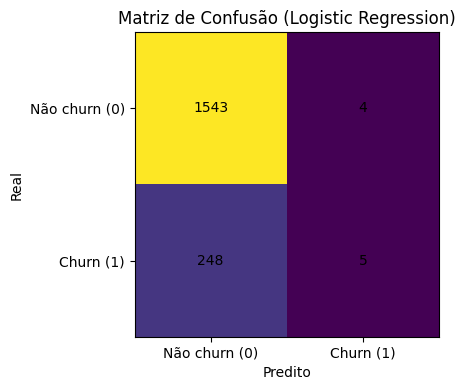

ROC-AUC Modelo 1: 0.7398228370095377


In [13]:
# classification_report
print(classification_report(y_test, y_pred))
CriarConfusao(y_test, y_pred)
print("ROC-AUC Modelo 1:", roc_auc_score(y_test, y_prob))

**🔎 Detalhando a Matriz de Confusão**

| **Real \ Predito** | **Não churn (0)** | **Churn (1)** | **Total Real** |
| ------------------ | ----------------- | ------------- | -------------- |
| **Não churn (0)**  | 1542 (TN)         | 5 (FP)        | 1547           |
| **Churn (1)**      | 248 (FN)          | 5 (TP)        | 253            |
| **Total Predito**  | 1790              | 10            | 1800           |




#### 📊 Primeiro: contexto numérico ####

- **Total de amostras:** 1800
- **Classe 0** → 1547 (86%) - não churn
- **Classe 1** → 253 (14%) - churn

**O que significa?**

- Recall 1.00 → O modelo acertou praticamente TODOS os 0.
- Ele quase nunca erra dizendo que algo é classe 1 quando é 0.
- Está excelente em reconhecer a classe majoritária.
- Mas isso é fácil… porque 86% do dataset é classe 0.

**🔴 Classe 1 (a importante)**

- **recall** = 0.02 (aqui está o problema)
    -  O modelo detectou apenas 2% dos casos da classe 1.
    -  De 253 casos reais da classe 1 ele está acertando aproximadamente 5 casos, ou seja, ele praticamente ignora a classe 1.
- **precision** = 0.50
    - Quando ele prevê classe 1, acerta metade das vezes.
    - Mas isso é irrelevante se quase nunca prevê 1.
- **f1-score** = 0.04
    - Esse valor é praticamente zero.

**🎯 Accuracy = 0.86**

Isso parece ótimo…, mas observe:
Se você criasse um modelo burro que sempre prevê 0:
- Ele acertaria 1547 de 1800
- Accuracy = 86%
Ou seja:
- Seu modelo pode estar fazendo quase nada além de prever a classe majoritária.

#### 📊 Macro vs Weighted ####

**🔹 Macro Avg**
- precision = 0.68
- recall = 0.51
- f1-score = 0.48

Média simples entre classes.

Não considera o tamanho.

Aqui vemos o desempenho real médio: ruim.


#### 🧠 Diagnóstico Técnico ####

Esse modelo está:

    ✅ Muito bom na classe majoritária

    ❌ Péssimo na classe minoritária

    ⚠ Enganando com accuracy alta


Clássico problema de:

- Desbalanceamento
- Threshold mal ajustado
- Modelo não penalizado corretamente
------------------------------------------------------------------------------------
### 🚀 O que você pode fazer agora? ###

1. Ajustar class_weight='balanced'
2. Testar SMOTE
3. Ajustar threshold (não usar 0.5 fixo)
4. Avaliar ROC-AUC e PR-AUC
5. Analisar matriz de confusãoas
------------------------------------------------------------------------------------

##  Nova Bateria de Testes ##

## 1. Ajustando class_weight para 'balanced' - Modelo 2 ## 

**🧠 O que significa class_weight="balanced"?**

É um mecanismo que diz ao modelo:

>“Erros na classe rara são mais graves.
Dê mais atenção a ela.”

Ele ajusta automaticamente o peso das classes com base na frequência:


In [14]:
#############################################################################
## esse código LaTex é apenas para escrever a fórmula
from IPython.display import display, Math, Latex
display(Math(r'peso =\frac{n_{samples}}{n_{classes} . {n_{classe_i}}}'))
#############################################################################

<IPython.core.display.Math object>

Isso significa que:
- A classe rara recebe peso maior
- A classe comum recebe peso menor

**🎲 Analogia simples**

Imagine que estamos ensinando uma criança a classificar frutas:
- 80 maçãs
- 20 laranjas

Se ela errar uma maçã → pouco problema
Se ela errar uma laranja → problema maior

Então você diz:

>“Errar laranja vale 4 vezes mais.”

Isso é class_weight="balanced".

**🧠 O que isso muda no treino?**

Durante o treinamento:
- Se o modelo errar um churn, ele “sofre” mais penalização.
- Se errar um não-churn, a penalização é menor.

Isso força o modelo a:
- ajustar a fronteira de decisão
- prestar mais atenção na classe minoritária

**📌 Importante: o que NÃO muda**

class_weight:
- NÃO muda os dados
- NÃO muda o threshold 0.5
- NÃO cria novos exemplos
- NÃO faz oversampling

Ele apenas muda o “peso do erro” no cálculo da função de perda.
**📌 Por que usar?**

Em churn normalmente temos:
- 70–80% não churn
- 20–30% churn

Sem ajuste:
- modelo pode prever tudo como 0 (não churn)
- alta acurácia
- recall péssimo

Com balanced:
- penaliza mais erro na classe minoritária
- melhora recall do churn

**📌 Funciona com quais modelos?**

Funciona diretamente em:
- LogisticRegression
- RandomForestClassifier
- DecisionTreeClassifier
- SVC

Nem todos modelos suportam.

**🔎 Quando usar?**

Use quando:
- classes são desbalanceadas
- você se importa com a classe rara
- churn, fraude, doença, risco

**⚠️ Quando não usar?**

- quando dataset já está balanceado
- quando já aplicou SMOTE
- quando quer maximizar accuracy pura

              precision    recall  f1-score   support

           0       0.93      0.69      0.79      1547
           1       0.26      0.68      0.38       253

    accuracy                           0.69      1800
   macro avg       0.60      0.68      0.59      1800
weighted avg       0.84      0.69      0.73      1800



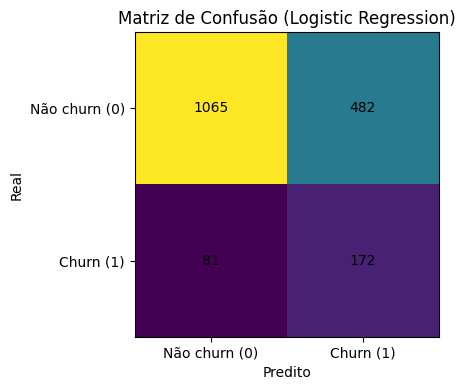

ROC-AUC Modelo 2: 0.7413788257778027


In [15]:
# Alterando o parâmetro para o novo modelo
model2 = Pipeline([
    ("preprocess", preprocessor), 
    ("classifier", LogisticRegression(max_iter=5000,
                                      class_weight="balanced", 
                                      solver="lbfgs"
     ))  
])
# ======================
# Treinamento do novo modelo
# ======================

model2.fit(X_train, y_train)

# Predição de classe (0/1) com threshold padrão (0.5)
y_pred2 = model2.predict(X_test)

# Probabilidade da classe positiva (churn = 1)
# predict_proba retorna duas colunas: P(classe 0) e P(classe 1)
y_prob2 = model2.predict_proba(X_test)[:, 1]


# classification_report
print(classification_report(y_test, y_pred2))
CriarConfusao(y_test, y_pred2)
# ROC-AUC 
print("ROC-AUC Modelo 2:", roc_auc_score(y_test, y_prob2))

|            | Predito 0 | Predito 1 |
| ---------- | --------- | --------- |
| **Real 0** | 1062      | 485       |
| **Real 1** | 80        | 173       |

Total = 1800

**Identificando os componentes**

TN (Verdadeiro Negativo) = 1062

FP (Falso Positivo) = 485

FN (Falso Negativo) = 80

TP (Verdadeiro Positivo) = 173


### 🔎 Análise Técnica ###

#### 🔹 Classe 0 (não churn) ####

**Precision: 0.93**
→ Quando o modelo prevê “não churn”, ele acerta 93% das vezes.

**Recall: 0.69**
→ Ele identifica 69% dos clientes que realmente não iriam sair.

**F1-score: 0.79**
→ Bom equilíbrio entre precisão e recall.

**Support: 1547**
→ Total real dessa classe.

✔ Continua bom na classe majoritária, mas agora menos “perfeito” que antes.

#### 🔴 Classe 1 (churn) ####

**Precision: 0.26**
→ Quando o modelo prevê churn, ele só acerta 26% das vezes.
(Muitos falsos positivos.)

**Recall: 0.68**
→ Agora ele identifica 68% dos clientes que realmente vão sair.

Grande diferença em relação ao modelo anterior:
- **Antes:** recall 0.02
- **Agora:** recall 0.68

Ou seja, você saiu de um modelo que ignorava churn para um modelo que realmente detecta churn.

**F1-score: 0.38**
→ Melhor que 0.04 anterior, mas ainda modesto.

**Support: 253**

**Accuracy: 0.69**

- Caiu de 0.86 para 0.69.
- Mas isso é esperado.
- Você deixou de privilegiar a classe majoritária e começou a capturar churn.

#### Médias ####
**Macro Avg= 0.58 (F1)**
- Média simples entre classes.
- Mostra equilíbrio melhor do que antes.

**Weighted Avg = 0.73 (F1)**
- Ponderado pelo tamanho das classes.
- Desempenho razoável considerando maioria
  
------------------------------------------------------------------------------------

### 🧠 Interpretação Estratégica ###

**Agora o modelo:**

**✔ Detecta a maioria dos churns**

**✔ Tem recall equilibrado entre classes (~0.69)**

**❌ Gera muitos falsos positivos**

Mas em churn, isso costuma ser aceitável.

Porque:
- Falso positivo → você oferece desconto a quem não ia sair
- Falso negativo → você perde cliente
- Normalmente o custo do FN é maior.

------------------------------------------------------------------------------------

### 💰 Interpretação de negócio ###

Isso significa:

- Você vai oferecer retenção para 658 clientes (173+485)
- Mas só 173 realmente iam sair
- Se o custo da retenção for baixo, ótimo.





              precision    recall  f1-score   support

           0       0.93      0.70      0.80      1547
           1       0.27      0.68      0.38       253

    accuracy                           0.69      1800
   macro avg       0.60      0.69      0.59      1800
weighted avg       0.84      0.69      0.74      1800



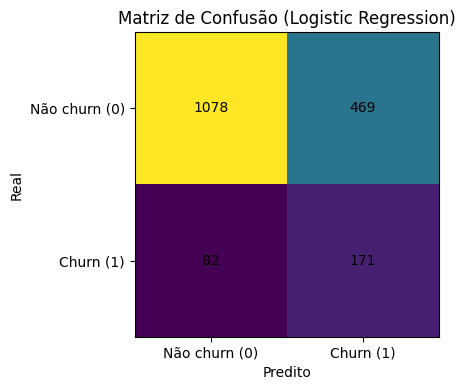

ROC-AUC: 0.7397206374188472


In [16]:
# Usando imblearn:

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

model_smote = Pipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=5000))
])

model_smote.fit(X_train, y_train)

# Observe:
# SMOTE acontece apenas dentro do treino, depois do preprocess.
# Isso é correto.


# Previsão padrão (threshold = 0.5)
y_pred_smote = model_smote.predict(X_test)

# Probabilidades
y_prob_smote = model_smote.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_smote))
CriarConfusao(y_test, y_pred_smote)
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))

### 🔎 Análise Técnica ###

**📌 Recall do churn**

✔ Continua alto (~68%)

Ou seja, o modelo continua detectando a maioria dos churns.

**📌 Precision do churn**

Precision≈0.27

Praticamente igual ao modelo com class_weight .

**📌 Accuracy**

Accuracy≈0.69

Também muito parecido com o modelo balanceado.

**🎯 Concluão**

SMOTE:

✔ Ajudou a equilibrar treino

✔ Manteve recall alto

❌ Não aumentou separação real entre classes

Foram testados três modelos:

1️⃣ Modelo original

2️⃣ class_weight='balanced'

3️⃣ SMOTE

E todos têm ROC-AUC ~0.74.

Isso mostra que:

- O ranking das probabilidades já estava bom
- O limite está na capacidade do modelo
- O gargalo não é apenas desbalanceamento

## 3. Ajustando o threshold - Modelo 4 ## 

**🧠 O que significa "Ajustar o Threshold"?**

Seu modelo não decide “sim” ou “não” diretamente.

Ele calcula uma probabilidade.

Exemplo:

- Cliente A → 0.82 (82% de chance de churn)
- Cliente B → 0.47 (47% de chance)
- Cliente C → 0.15 (15% de chance)

Mas em algum momento você precisa decidir:

> A partir de que número eu considero que ele vai sair?

Esse número é o threshold (limiar).


**Normalmente o valor do threshold é 0.5**

Regra padrão:

- Se probabilidade ≥ 0.5 → classifica como churn
- Se probabilidade < 0.5 → não churn

Mas isso é apenas uma convenção.

### 📌 Ajustar significa mudar essa régua ###

#### 🎯 Se eu baixar o threshold para 0.3: ####

Agora qualquer cliente com 30% de chance já é considerado churn.

**Resultado:**

- Você identifica mais churns
- Mas aumenta falsos positivos

Seu modelo fica mais “sensível”.

#### 🎯 Se eu subir o threshold para 0.7: ####

Agora só clientes com 70% de chance entram como churn.

**Resultado:**

- Menos falsos positivos
- Mas você perde alguns churns reais

Seu modelo fica mais “conservador”.


=== 🎯 Classification Report | Model 4.1 - Fixed Threshold = 0.3 ===

              precision    recall  f1-score   support

           0       0.95      0.37      0.53      1547
           1       0.18      0.88      0.30       253

    accuracy                           0.44      1800
   macro avg       0.57      0.62      0.42      1800
weighted avg       0.84      0.44      0.50      1800



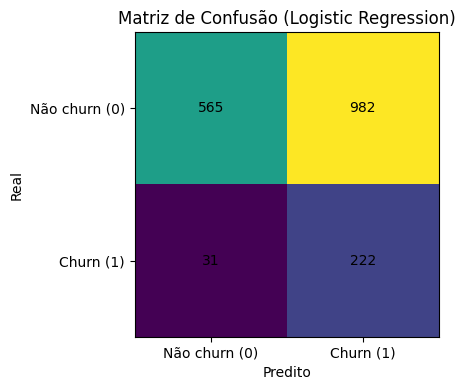

ROC-AUC: 0.7413788257778027

=== Graph Precision-Recall Curve  | Model 4.2 - Best Threshold (max F1)= 0.5658 ===



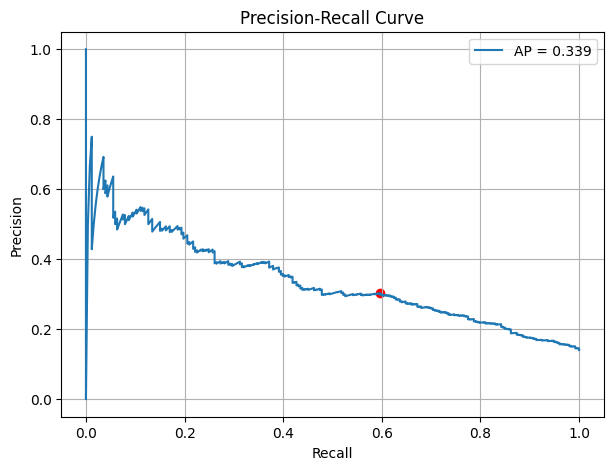


Detalhes do melhor ponto:
Best threshold: 0.5658230438562593
Precision: 0.3026052104208417
Recall: 0.5968379446640316
F1: 0.40159574468040454

=== Classification Report | Model 4.2 - Best Threshold (max F1) = 0.5658 ===

              precision    recall  f1-score   support

           0       0.92      0.78      0.84      1547
           1       0.30      0.60      0.40       253

    accuracy                           0.75      1800
   macro avg       0.61      0.69      0.62      1800
weighted avg       0.83      0.75      0.78      1800



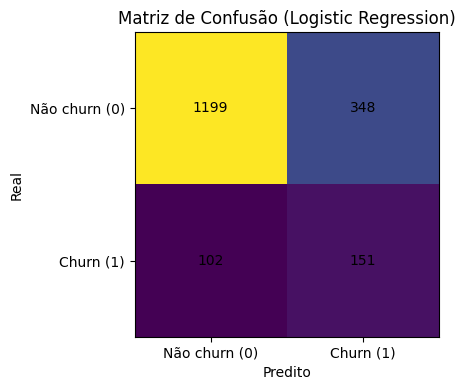

ROC-AUC: 0.7413788257778027


In [17]:
# Alterando o parâmetro para o novo modelo
model4 = Pipeline([
    ("preprocess", preprocessor), 
    ("classifier", LogisticRegression(max_iter=5000
                    ,class_weight="balanced"
     ))  
])


# =============================
# Treinamento do novo modelo
# =============================

model4.fit(X_train, y_train)

# Probabilidade da classe positiva (churn = 1)
# predict_proba retorna duas colunas: P(classe 0) e P(classe 1)
y_prob4 = model4.predict_proba(X_test)[:, 1]

# ============================================================
# EXEMPLO 1 — Threshold FIXO (ex.: 0.30)
# ============================================================
threshold_fixed = 0.30

# Converte probabilidade em classe (0/1) usando threshold fixo
y_pred_fixed = (y_prob4 >= threshold_fixed).astype(int)

print("\n=== 🎯 Classification Report | Model 4.1 - Fixed Threshold =", threshold_fixed, "===\n")
print(classification_report(y_test, y_pred_fixed))
CriarConfusao(y_test, y_pred_fixed)
print("ROC-AUC:", roc_auc_score(y_test, y_prob4))

# ============================================================
# EXEMPLO 2 — Melhor Threshold (maximizando F1 via PR curve)
# ============================================================
# precision_recall_curve retorna precision/recall para vários thresholds possíveis
precision, recall, thresholds = precision_recall_curve(y_test, y_prob4 )

# thresholds tem tamanho (len(precision)-1), então calculamos F1 alinhado
# Adicionamos 1e-12 para evitar divisão por zero.
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)


# escolhendo o melhor threshold com base no maior F1 [ argmax(f1_scores) ]
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]


# Separando visualmente os testes 4.1 e 4.2 
#print("\n=== Graph Precision-Recall Curve  | Model 4.2 - Best Threshold =", best_threshold, "===\n") #sem arredondar o best_threshold

# best_threshold arredondado
print("\n=== Graph Precision-Recall Curve  | Model 4.2 - Best Threshold (max F1)=",  round(float(best_threshold), 4), "===\n")

# calcular Average Precision (AP)
ap = average_precision_score(y_test, y_prob4)

# Gerando o gráfico para mostrar o ponto 
# plot
plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f'AP = {ap:.3f}')
#marcando o ponto específico no gráfico (Melhor Threshold) 
plt.scatter(recall[best_idx], precision[best_idx], color='red')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

print("\nDetalhes do melhor ponto:")
print("Best threshold:", float(best_threshold))
print("Precision:", float(precision[best_idx]))
print("Recall:", float(recall[best_idx]))
print("F1:", float(f1_scores[best_idx]))



# Predição com o melhor threshold encontrado
y_pred_best = (y_prob4 >= best_threshold).astype(int)

print("\n=== Classification Report | Model 4.2 - Best Threshold (max F1) =", round(float(best_threshold), 4), "===\n")
print(classification_report(y_test, y_pred_best))
CriarConfusao(y_test, y_pred_best)
print("ROC-AUC:", roc_auc_score(y_test, y_prob4))




### 🔎 Análise Técnica ###

#### 📊 Model 4.1️⃣ Threshold = 0.30 (agressivo) ####

**📌 Métricas principais**

- Recall churn: 0.88
- Precision churn: 0.18
- Accuracy: 0.44

**🔎 Matriz de Confusão**

- TP = 222 (verdadeiros positivos)
- FN = 31  (falsos negativos)
- FP = 982 (falsos positivos) 
- TN = 565 (verdadeiros negativos)

**🧠 Interpretação técnica**

Você está capturando:

- 88% dos churners reais
- Ao custo de 982 clientes que não iam churnar sendo tratados como churn

**⚠️⚠️⚠️Isso é over-alerta extremo. ⚠️⚠️⚠️**

------------------------------------------------------------------------------------
#### 💰 Interpretação de negócio ####

Se você oferecer desconto para todos classificados como churn:

- 222 eram realmente churn
- 982 não eram

Ou seja:

- 82% das ações de retenção seriam desperdício.
**Isso só vale a pena se:**
- Custo de retenção for muito baixo
- LTV for muito alto 

------------------------------------------------------------------------------------
**📌 O que significa LTV ?**

LTV = Lifetime Value (Valor do Cliente ao Longo do Tempo)

Em outras palavras:

>É o quanto um cliente gera de receita (ou lucro) durante todo o relacionamento com a empresa.


**📌 O que significa “LTV for muito alto”?**

Significa que:

- o cliente gera muita receita ao longo do tempo
- é financeiramente valioso
- vale a pena investir para reter

**🧠 Interpretação estratégica**

Se LTV é alto:

✔️ Você pode gastar mais em marketing para adquiri-lo
✔️ Pode oferecer descontos para reter
✔️ Pode priorizar atendimento

Se LTV é baixo:

❌ Não faz sentido gastar muito para manter
❌ Campanhas caras não compensam

------------------------------------------------------------------------------------


#### 📊 Model 4.2️⃣ Threshold “ótimo” (max F1 ≈ 0.5658) ####

**📌 Métricas principais**

- Recall churn: 0.60
- Precision churn: 0.30
- Accuracy: 0.75
- F1 churn: 0.40

**🔎 Matriz de Confusão**

- TP = 151
- FN = 102
- FP = 348
- TN = 1199

**🧠 Interpretação técnica**

Esse ponto é mais equilibrado:

- Recupera 60% dos churners
- Reduz drasticamente falsos positivos
- Mantém modelo operacionalmente viável

Esse threshold é estatisticamente equilibrado, mas não necessariamente o melhor para negócio.

------------------------------------------------------------------------------------
### 🔬 Comparação direta entre os Modelos 4.1 e 4.2 ###

| Métrica           | Threshold 0.30 | Threshold F1 |
| ----------------- | -------------- | ------------ |
| Recall churn      | 🔥 0.88        | 0.60         |
| Precision churn   | 0.18           | 🔼 0.30      |
| Falsos positivos  | 982            | 348          |
| Ações desperdício | Muito alto     | Moderado     |
| Accuracy          | 0.44           | 0.75         |


#### 🎯 Qual é melhor? ####

Depende da política da empresa.

**Cenário A — Empresa agressiva em retenção**

- Prefere errar para mais
- Quer evitar churn a qualquer custo
- Threshold 0.30 faz sentido

**Cenário B — Empresa quer eficiência**
- Só quer agir onde risco é forte
- Prefere menos desperdício
- Threshold F1 é mais adequado

**🧠 Insight mais importante até agora**

O modelo **NÃO** está ruim.

Ele está:

>Sensível à política de decisão.

E isso é exatamente o que churn exige.

------------------------------------------------------------------------------------

## 4. Avaliando ROC-AUC e PR-AUC ##

#### 📌 ROC-AUC e PR-AUC são métricas. ####
> Mas elas medem coisas diferentes.

#### 📌 Por que elas existem? ####

Porque quando temos:

- Classe desbalanceada (como churn)
- Probabilidades em vez de apenas 0 ou 1
- Interesse em ranking de risco

Accuracy deixa de ser suficiente.

Então usamos métricas que avaliam a **qualidade da separação do modelo**.

------------------------------------------------------------------------------------
#### 📈 ROC-AUC  ####

**ROC-AUC** significa Receiver Operating Characteristic - Area Under the Curve)

Em português: 

> Área sob a Curva da Característica de Operação do Receptor

👉 É uma métrica de desempenho amplamente utilizada em aprendizado de máquina para avaliar modelos de classificação binária (onde o objetivo é distinguir entre duas classes, ex: "sim" ou "não", "doente" ou "saudável", "churn" ou "não churn"...). 

**ROC-AUC mede separação global entre as classes:**

Bom para comparar modelos, mesmo com classes desbalanceadas

**Imagine o nosso estudo de caso**

Você pega:

- Um cliente que vai churnar
- Um cliente que não vai churnar

Pergunta:

> O modelo deu score maior para o churn?

Se a resposta for sim, ponto para o modelo.

ROC-AUC mede:

> Em quantas vezes isso acontece corretamente.

Interpretação prática

- 0.5 → Modelo aleatório (cara ou coroa)
- 0.7 → Modelo razoável
- 0.8 → Muito bom
- 0.9 → Excelente
- 1.0 → Perfeito

Nosso modelo teve algo perto de 0.74 em um momento.

Isso significa:

> Em 74% das vezes, ele dá score maior para churn do que para não churn.

Isso é capacidade de separação.

**🔬 O que o ROC realmente mede?**

Ele considera:

- Sensibilidade (Recall)
- Taxa de falso positivo

Para todos os thresholds possíveis.

Importante:

ROC-AUC não depende do threshold fixo.

------------------------------------------------------------------------------------

#### 📈 PR-AUC (Precision-Recall AUC)  ####


**PR-AUC** significa Precision-Recall Area Under the Curve 

Em português:

> Área Sob a Curva de Precisão-Revocação.

👉 É uma métrica de aprendizado de máquina utilizada para avaliar o desempenho de modelos de classificação binária, sendo especialmente útil quando as classes estão desbalanceadas (ex: detecção de fraudes, onde há poucas transações fraudulentas e muitas normais, ou em churn, onde há pouca amostra de churn, como no nosso caso). 


Aqui estão os pontos principais sobre o PR-AUC:

- **O que avalia:** Mede a troca (trade-off) entre a Precisão (quanto o modelo é assertivo ao prever um positivo) e a Revocação/Recall (quanto o modelo consegue encontrar de todos os positivos reais) em diferentes limiares de decisão.
- **Valor e Interpretação:** O valor da PR-AUC varia de 0,0 a 1,0. Quanto mais próximo de 1,0, melhor o desempenho do modelo.
- **Vantagem em Classes Desbalanceadas:** Ao contrário da curva ROC-AUC, a curva PR-AUC não considera os verdadeiros negativos, focando apenas nos erros de falsos positivos e falsos negativos, o que a torna superior para cenários onde a classe positiva é rara.
- **Curva Pr-AUC ideal:** O classificador perfeito apresenta uma área de 1,0, indicando alta precisão e alta revocação. 
Em resumo, o PR-AUC é a métrica ideal para saber o quanto o seu modelo consegue identificar a classe minoritária de interesse sem gerar muitos alarmes falsos. 


Agora entra o ponto mais importante para churn.

PR-AUC mede:

> Quando o modelo diz que alguém vai churnar, ele está certo?

E:

> Ele está encontrando os churners reais?

Ela avalia o equilíbrio entre:

- Precision
- Recall

Imagine que o modelo cria um ranking de risco.

Se você começar a ligar para os clientes com maior score:

PR-AUC mede:

> Quão eficiente é esse ranking na parte de cima?

Em churn (classe rara), isso é MUITO mais relevante que ROC.

------------------------------------------------------------------------------------

### 🚨 Por que ROC pode enganar em base desbalanceada? ###

Porque:

Se 86% não churn, o modelo pode ter boa taxa de separação mesmo sendo ruim em identificar churn real.

ROC não penaliza tanto falso positivo quando classe negativa é grande.

PR-AUC penaliza mais.

------------------------------------------------------------------------------------

### 🔎 Análise técnica ROC-AUC ###



In [18]:
print("ROC-AUC Modelo 1 (Original):", roc_auc_score(y_test, y_prob))
print("ROC-AUC Modelo 2 (Balanceado):", roc_auc_score(y_test, y_prob2))
print("ROC-AUC Modelo 3 (SMOTE:):", roc_auc_score(y_test, y_prob_smote))
print("ROC-AUC Modelo 4.1 (Threshold fixo):", roc_auc_score(y_test, y_prob4))
print("ROC-AUC Modelo 4.2 (Melhor threshold):", roc_auc_score(y_test, y_prob4))

ROC-AUC Modelo 1 (Original): 0.7398228370095377
ROC-AUC Modelo 2 (Balanceado): 0.7413788257778027
ROC-AUC Modelo 3 (SMOTE:): 0.7397206374188472
ROC-AUC Modelo 4.1 (Threshold fixo): 0.7413788257778027
ROC-AUC Modelo 4.2 (Melhor threshold): 0.7413788257778027



| Modelo | Estratégia       | ROC-AUC    |
| ------ | ---------------- | ---------- |
|   1    | Original         | **0.7398** |
|   2    | Class Weight     | **0.7414** |
|   3    | SMOTE            | **0.7397** |
|  4.1   | Threshold fixo   | **0.7414** |
|  4.2   | Melhor threshold | **0.7414** |


#### 🎯 Primeira conclusão (importante) ####

Todos os modelos estão praticamente no mesmo nível:

> ≈ 0.74

A diferença máxima entre eles é cerca de **0.002**.

Isso é estatisticamente muito pequeno.

Em termos práticos:
👉 Todos têm praticamente a mesma capacidade de separação.

**📌 O que isso revela?**

Nosso modelo já tinha:

✔ Um ranking razoável

✔ Separação moderada entre churn e não churn

Mas não excelente.

0.74 é:
- Melhor que aleatório (0.5)
- Mas longe de excelente (>0.85)

------------------------------------------------------------------------------------
#### 🧠 Observação ####


ROC-AUC mede:

> O quão bem o modelo ordena os clientes do mais arriscado para o menos arriscado.

Ele **NÃO** depende do threshold.

Por isso:

- Threshold fixo ou melhor threshold → mesmo ROC
- class_weight muda comportamento → mas quase não muda separação
- SMOTE → não mudou ranking das probabilidades

------------------------------------------------------------------------------------

#### 🚨 Conclusão técnica importante ####

O gargalo não é:

- Desbalanceamento
- Threshold
- Ajuste leve de peso

O gargalo é a capacidade da regressão logística de capturar o padrão.

Provavelmente:

- Relações não lineares
- Interações entre variáveis
- Padrões mais complexos
------------------------------------------------------------------------------------

### 🔎 Análise técnica PR-AUC ###

Agora sim estamos olhando a métrica certa para churn 👏


👉 A PR é a métrica mais adequada para churn porque ela foca diretamente na qualidade das previsões da classe que realmente importa: os clientes que vão cancelar. Em problemas de churn, essa classe costuma ser minoritária, e o que interessa não é apenas separar bem os grupos, mas garantir que, quando o modelo aponta alguém como risco, isso faça sentido.

👉 A curva Precision-Recall avalia o equilíbrio entre encontrar a maior parte dos clientes que realmente vão sair e evitar marcar como risco muitos clientes que não sairiam. Como a precisão diminui quando há muitos falsos positivos, a PR evidencia rapidamente quando o modelo está sendo “alarmista” demais. Por isso, em cenários desbalanceados como churn, a PR-AUC reflete de forma mais fiel o valor prático do modelo do que métricas que não penalizam tanto os erros na classe minoritária.

**🎯 Resumindo**

- ROC mede capacidade de separação.
- PR mede qualidade da decisão na classe rara.

E churn é classe rara.




In [19]:
print("PR-AUC Modelo 1 (Original):", average_precision_score(y_test, y_prob))
print("PR-AUC Modelo 2 (Balanceado):", average_precision_score(y_test, y_prob2))
print("PR-AUC Modelo 3 (SMOTE:):", average_precision_score(y_test, y_prob_smote))
print("PR-AUC Modelo 4.1 (Threshold fixo):", average_precision_score(y_test, y_prob4))
print("PR-AUC Modelo 4.2 (Melhor threshold):", average_precision_score(y_test, y_prob4))


PR-AUC Modelo 1 (Original): 0.33356348727726887
PR-AUC Modelo 2 (Balanceado): 0.3386471861350494
PR-AUC Modelo 3 (SMOTE:): 0.33795486654875795
PR-AUC Modelo 4.1 (Threshold fixo): 0.3386471861350494
PR-AUC Modelo 4.2 (Melhor threshold): 0.3386471861350494


| Modelo | Estratégia       | PR-AUC     |
| ------ | ---------------- | ---------- |
| 1      | Original         | **0.3336** |
| 2      | Class Weight     | **0.3386** |
| 3      | SMOTE            | **0.3380** |
| 4.1    | Threshold fixo   | **0.3386** |
| 4.2    | Melhor threshold | **0.3386** |


#### 🎯 Primeira leitura ####

Todos os modelos estão na faixa:

> ≈ 0.33 – 0.34

Diferença máxima ≈ 0.005

Isso é pequeno.

Ou seja:

👉 Assim como no ROC-AUC, os modelos têm praticamente o mesmo desempenho estrutural.


**📌 Agora vem a parte importante**

Se o churn representa ~14% do dataset:

Baseline aleatório ≈ 0.14

Nosso modelo está em ≈ 0.33

Isso significa:

✔ Ele é mais que o dobro do aleatório

✔ Tem poder preditivo real

❌ Mas ainda não é forte

**📌 O que isso revela?**

Todos os ajustes que você fizemos:

- class_weight
- SMOTE
- ajuste de threshold

Mudaram o comportamento final (matriz de confusão),

Mas não mudaram a capacidade real de separar churn.

O ranking das probabilidades praticamente não mudou.

------------------------------------------------------------------------------------

### 📈 Comparando ROC vs PR ###

>ROC ≈ 0.74
>PR ≈ 0.33

Isso é coerente com dataset desbalanceado.

- ROC parece “bonito”.
- PR mostra a dificuldade real.

**🚨 Regra prática usada no mercado**

Se a classe positiva < 20%:

👉 Prefira PR-AUC

Se classes são balanceadas:

👉 ROC é suficiente




In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_roc_curves(models: dict, X_test, y_test):
    """
    models: dict com {nome_modelo: pipeline_model}
    """
    plt.figure(figsize=(7,5))
    
    for name, mdl in models.items():
        y_prob = mdl.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    
    # linha aleatória
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("Comparação de Curvas ROC")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_pr_curves(models: dict, X_test, y_test):
    """
    PR Curve + AP (PR-AUC) para vários modelos.
    """
    plt.figure(figsize=(7,5))
    
    for name, mdl in models.items():
        y_prob = mdl.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)  # PR-AUC (AP)
        plt.plot(recall, precision, label=f"{name} (PR-AUC={ap:.3f})")
    
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Comparação de Curvas Precision-Recall")
    plt.legend()
    plt.tight_layout()
    plt.show()

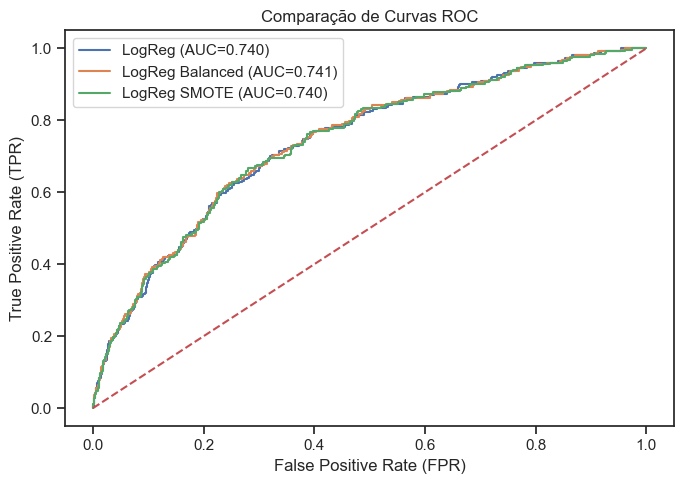

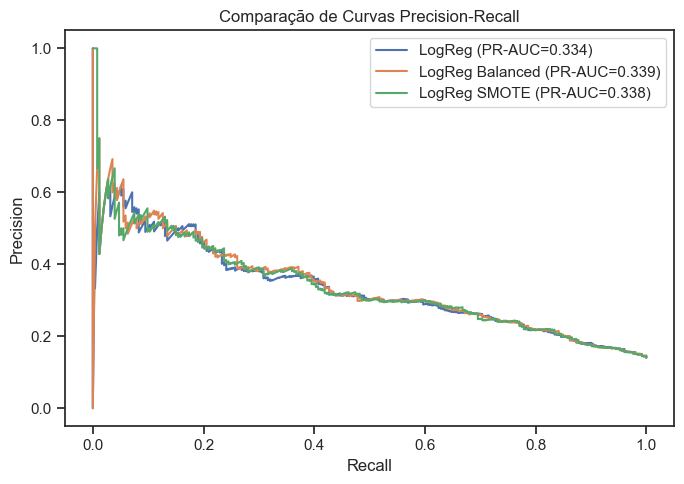

In [37]:
models = {
    "LogReg": model,
    "LogReg Balanced": model2,
    "LogReg SMOTE": model_smote
}
plot_roc_curves(models, X_test, y_test)
plot_pr_curves(models, X_test, y_test)

------------------------------------------------------------------------------------

### 🎯 Conclusão ###

Nós já extraímos quase tudo que a regressão logística linear consegue oferecer desse conjunto de variáveis.

👉 O gargalo não é balanceamento

👉 O gargalo é capacidade do modelo + qualidade das variáveis

------------------------------------------------------------------------------------

## 🚀 Os passos mais recomendados agora ##


### 1️⃣ Testar um modelo não linear (prioridade) ###

#### 🧠 O que esperar? ####

Se o novo modelo subir:

- **ROC** para 0.80+
- **PR**  para 0.40+

Você confirmou que havia padrão não linear.

Se não subir muito:

👉 O problema é feature engineering.

### 2️⃣ Se modelo não melhorar muito → trabalhar features ###
